In [1]:
import os 
os.listdir("./experiment_results/random_incompleteness_exp")

['knn_random_incompleteness_results.csv']

In [2]:
import pandas as pd
df = pd.read_csv("./experiment_results/random_incompleteness_exp/knn_random_incompleteness_results.csv")

In [3]:
df.columns

Index(['run', 'dataset', 'num_neighbors', 'removal', 'pqr',
       'all_data_hamm_loss', 'all_data_zero_loss', 'removed_data_hamm_loss',
       'removed_data_zero_loss'],
      dtype='object')

In [6]:
summary = (
    df.groupby(['dataset', 'num_neighbors', 'removal', 'pqr'])
      .agg(
          all_data_hamm_loss_mean=('all_data_hamm_loss', 'mean'),
          all_data_hamm_loss_std=('all_data_hamm_loss', 'std'),
          all_data_zero_loss_mean=('all_data_zero_loss', 'mean'),
          all_data_zero_loss_std=('all_data_zero_loss', 'std'),
          removed_data_hamm_loss_mean=('removed_data_hamm_loss', 'mean'),
          removed_data_hamm_loss_std=('removed_data_hamm_loss', 'std'),
          removed_data_zero_loss_mean=('removed_data_zero_loss', 'mean'),
          removed_data_zero_loss_std=('removed_data_zero_loss', 'std')
      )
      .reset_index()
)

In [7]:
knn_summary = (
    df.groupby(['dataset', 'num_neighbors'])
      .agg(
          all_data_hamm_loss_mean=('all_data_hamm_loss', 'mean'),
          all_data_hamm_loss_std=('all_data_hamm_loss', 'std'),
          all_data_zero_loss_mean=('all_data_zero_loss', 'mean'),
          all_data_zero_loss_std=('all_data_zero_loss', 'std'),
          removed_data_hamm_loss_mean=('removed_data_hamm_loss', 'mean'),
          removed_data_hamm_loss_std=('removed_data_hamm_loss', 'std'),
          removed_data_zero_loss_mean=('removed_data_zero_loss', 'mean'),
          removed_data_zero_loss_std=('removed_data_zero_loss', 'std')
      )
      .reset_index()
)

In [8]:
summary

,dataset,num_neighbors,removal,pqr,all_data_hamm_loss_mean,all_data_hamm_loss_std,all_data_zero_loss_mean,all_data_zero_loss_std,removed_data_hamm_loss_mean,removed_data_hamm_loss_std,removed_data_zero_loss_mean,removed_data_zero_loss_std
0,Family,5,0,0_0_0,0.289829,0.032384,0.977498,0.025853,NaN,NaN,NaN,NaN
1,Family,5,0,0_0_1,0.172842,0.011918,0.916292,0.025956,NaN,NaN,NaN,NaN
2,Family,5,0,0_1_0,0.167992,0.014587,0.919442,0.043950,NaN,NaN,NaN,NaN
3,Family,5,0,1_0_0,0.501275,0.055244,1.000000,0.000000,NaN,NaN,NaN,NaN
4,Family,5,0,1_1_1,0.660916,0.002904,1.000000,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
370,Family,25,70,0_0_0,0.355511,0.000606,1.000000,0.000000,0.375584,0.001037,1.000000,0.000000
371,Family,25,70,0_0_1,0.314756,0.001338,0.997750,0.002585,0.335258,0.002159,1.000000,0.000000
372,Family,25,70,0_1_0,0.308331,0.009926,0.991449,0.005895,0.328310,0.009080,0.998459,0.002639
373,Family,25,70,1_0_0,0.584733,0.025566,1.000000,0.000000,0.576752,0.022748,1.000000,0.000000


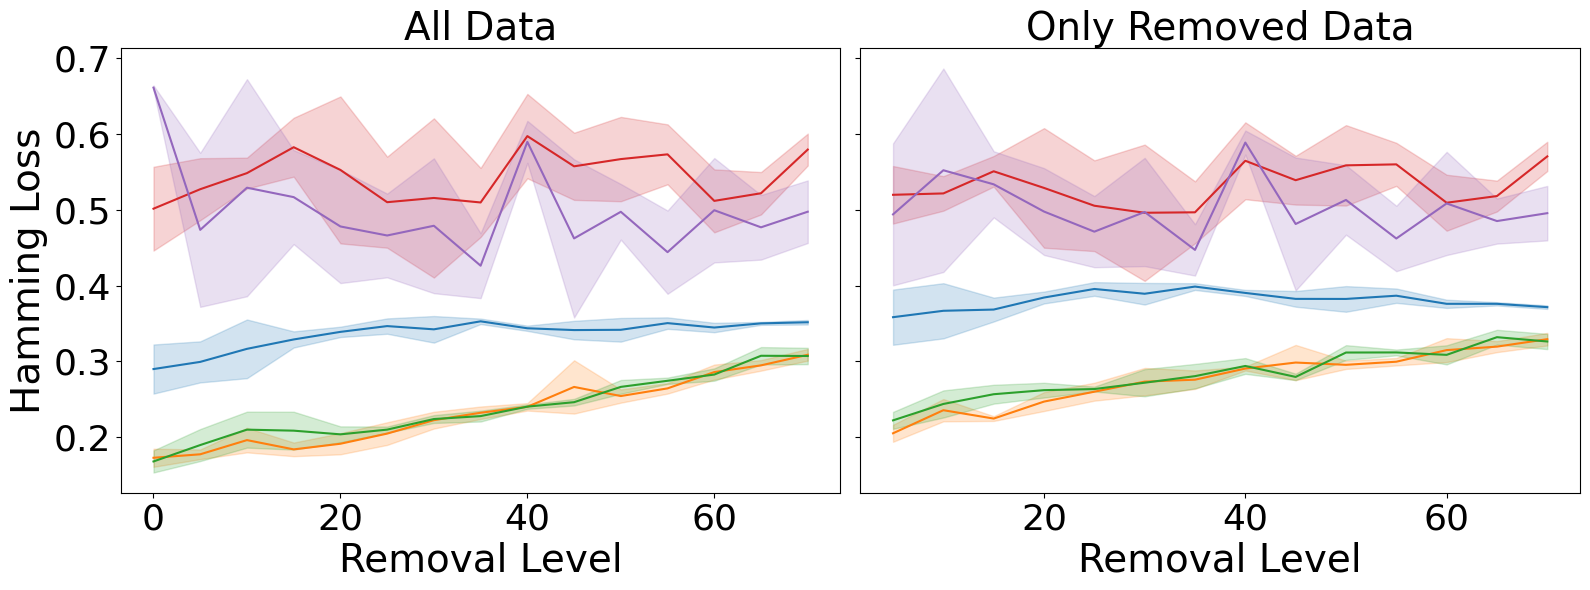

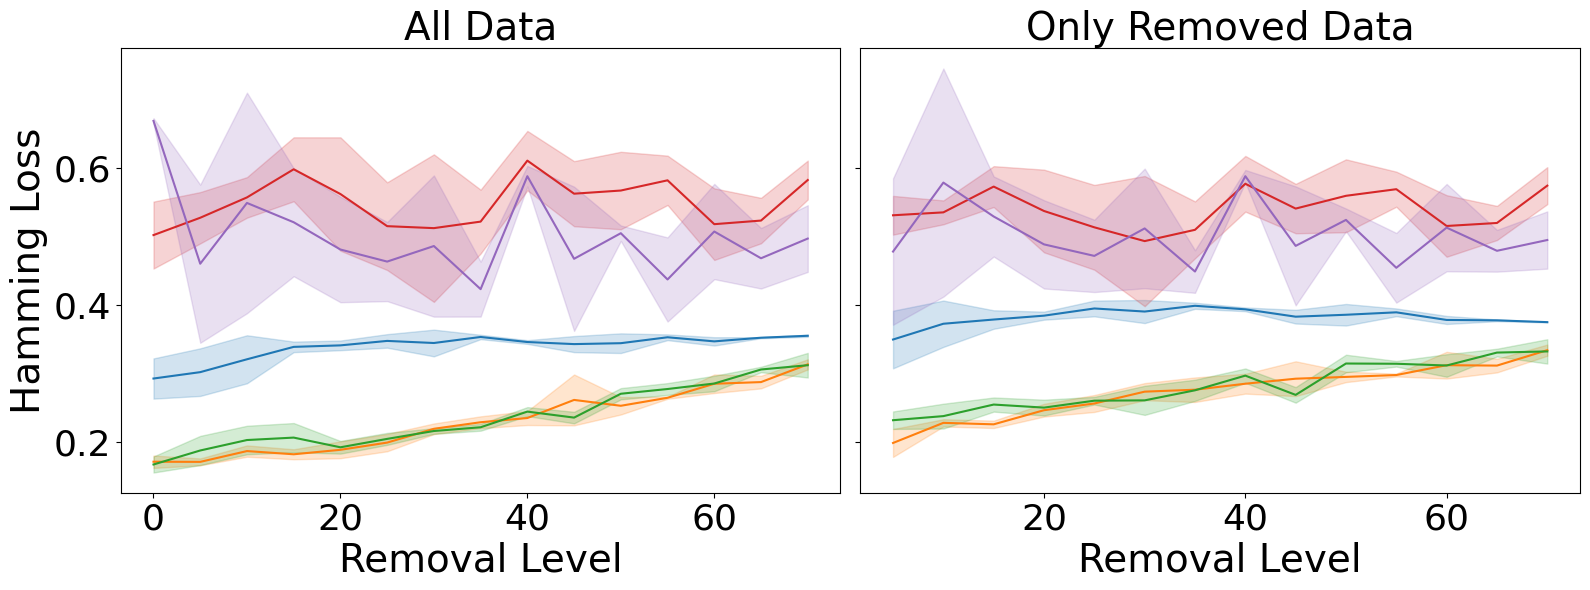

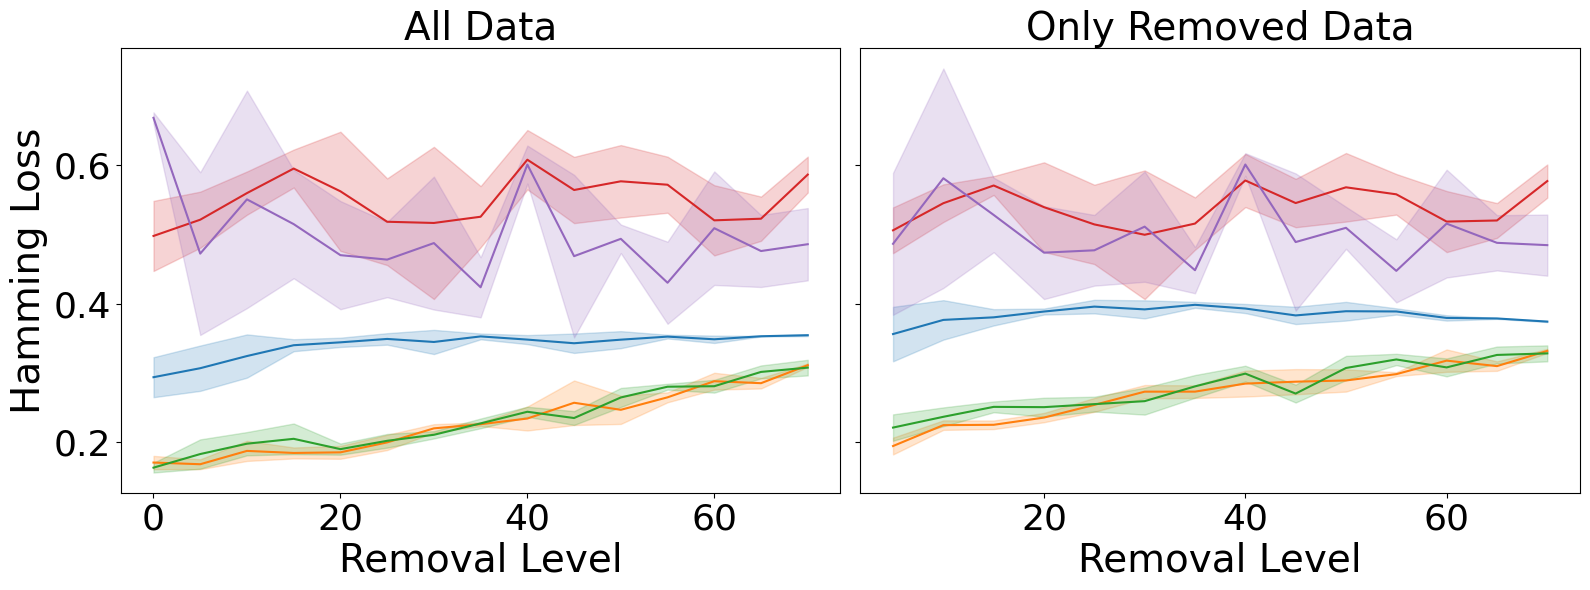

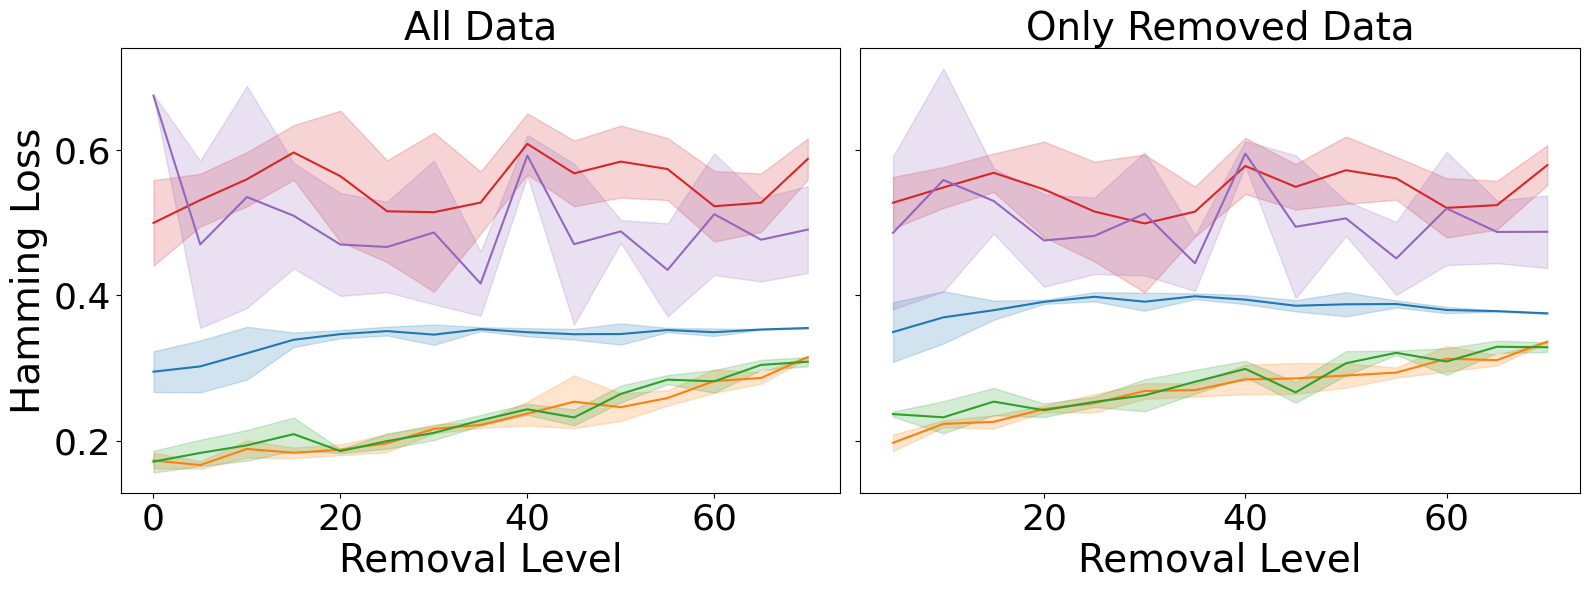

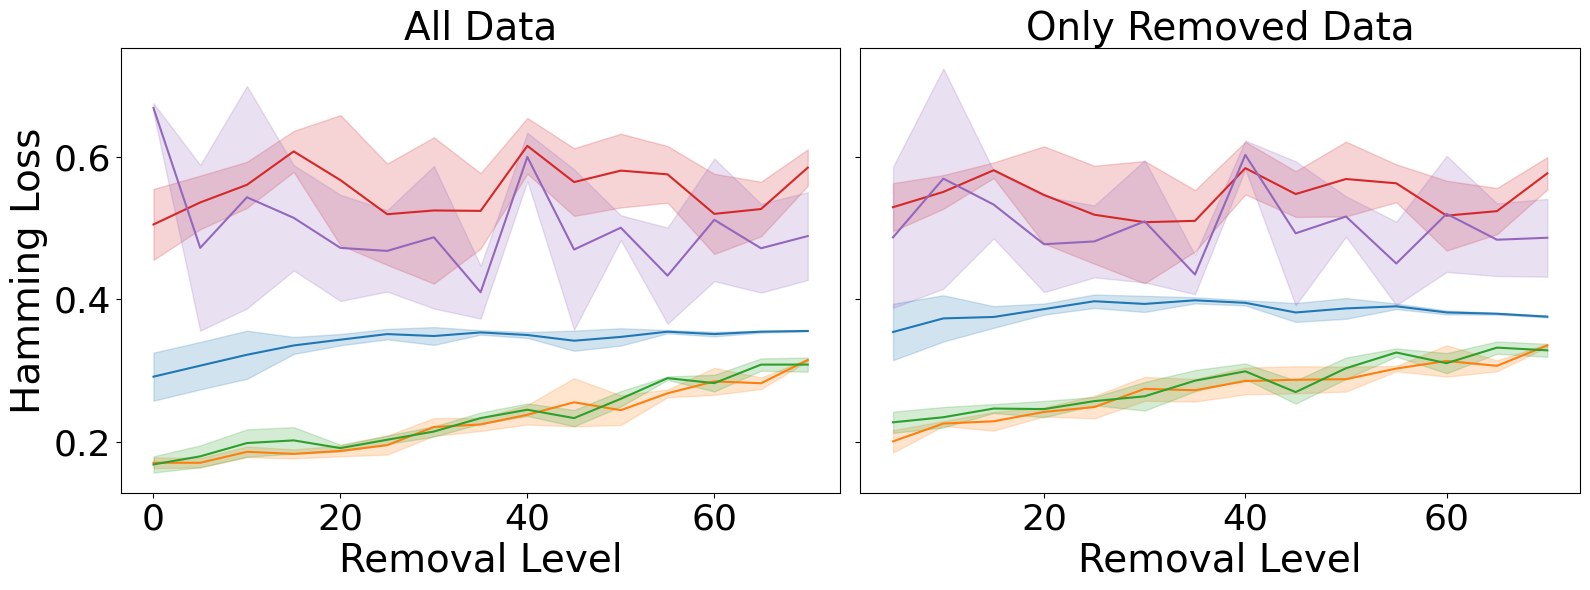

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate mean and std for losses
agg_df = df.groupby(['dataset', 'removal', 'pqr', 'num_neighbors']).agg(
    all_data_hamm_loss_mean=('all_data_hamm_loss', 'mean'),
    all_data_hamm_loss_std=('all_data_hamm_loss', 'std'),
    removed_data_hamm_loss_mean=('removed_data_hamm_loss', 'mean'),
    removed_data_hamm_loss_std=('removed_data_hamm_loss', 'std')
).reset_index()

datasets = agg_df['dataset'].unique()
methods = agg_df['pqr'].unique()
palette = sns.color_palette("tab10", len(methods))
num_neighbors_list = agg_df['num_neighbors'].unique()

# Loop over nearest neighbor values
for num_neighbors in sorted(num_neighbors_list):
    subset_neighbors = agg_df[agg_df['num_neighbors'] == num_neighbors]
    
    for dataset in datasets:
        subset_dataset = subset_neighbors[subset_neighbors['dataset'] == dataset]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
        
        for i, method in enumerate(methods):
            subset_method = subset_dataset[subset_dataset['pqr'] == method]
            
            # Plot for all data
            axes[0].plot(subset_method['removal'], subset_method['all_data_hamm_loss_mean'],
                         label=str(method), color=palette[i])
            axes[0].fill_between(
                subset_method['removal'],
                subset_method['all_data_hamm_loss_mean'] - subset_method['all_data_hamm_loss_std'],
                subset_method['all_data_hamm_loss_mean'] + subset_method['all_data_hamm_loss_std'],
                color=palette[i], alpha=0.2
            )
            
            # Plot for removed data
            axes[1].plot(subset_method['removal'], subset_method['removed_data_hamm_loss_mean'],
                         label=str(method), color=palette[i])
            axes[1].fill_between(
                subset_method['removal'],
                subset_method['removed_data_hamm_loss_mean'] - subset_method['removed_data_hamm_loss_std'],
                subset_method['removed_data_hamm_loss_mean'] + subset_method['removed_data_hamm_loss_std'],
                color=palette[i], alpha=0.2
            )
        
        axes[0].set_title(f'All Data', fontsize=28)
        axes[0].set_xlabel('Removal Level', fontsize=28)
        axes[0].set_ylabel('Hamming Loss', fontsize=28)
        axes[0].tick_params(axis='both', labelsize=26)  
        
        
        axes[1].set_title(f'Only Removed Data', fontsize=28)
        axes[1].set_xlabel('Removal Level', fontsize=28)
        axes[1].tick_params(axis='both', labelsize=26)  
        
        # axes[0].legend(title='Method (pqr)')
        plt.savefig(f"random_incompleteness_exp_{num_neighbors}.pdf", format='pdf', bbox_inches='tight')
        plt.tight_layout()
        plt.show()
